### Bonds Arbitrage

The main idea is to find mispricing, this allows (given some assumptions such as ability to short sell and no transaction fees) to exploit the mispricing and gain a risk-free profit 

By observing several bond prices and their future cash flows, we can build a system of linear equations. Solving this system gives the discount factors for different maturities

When no solution is possible, if the observed bond prices are inconsistent with any common set of discount factors, then at least one bond is mispriced relative to the others. In that case, an arbitrage portfolio may exist

$$
\begin{align}
P_1 &= C_{1,1}d_1 + C_{1,2}d_2 + C_{1,T}d_T \\
P_2 &= C_{2,1}d_1 + C_{2,2}d_2 + C_{2,T}d_T \\
\vdots \\
P_n &= C_{n,1}d_1 + C_{n,2}d_2 + C_{n,T}d_T \\
\end{align}
$$

$$
\begin{bmatrix}
C_{1,1} & C_{1,2} & \cdots & C_{1,T} \\
C_{2,1} & C_{2,2} & \cdots & C_{2,T} \\
\vdots & \vdots & \ddots & \vdots \\
C_{n,1} & C_{n,2} & \cdots & C_{n,T}
\end{bmatrix}
\begin{bmatrix}
d_1 \\
d_2 \\
\vdots \\
d_T
\end{bmatrix}
=
\begin{bmatrix}
P_1 \\
P_2 \\
\vdots \\
P_n
\end{bmatrix}
$$

where $P_i$ is the price of bond $i$, $d_t$ is teh discount rate at time $t$, and $C_{i,t}$ is the cash flow for bond $i$ at time $t$

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Consider the following bonds, all with face value F = 100
# 6m bond, 2% annual coupon         C = 2 --> C_1,1 = 1
# 1y bond, 4% annual coupon         C = 4 --> C_2,2 = 4
# 1.5y bond, 5% semiannual coupon   C = 5 --> C_3,1, C_3,2, C_3,3 = 2.5
# 2y bond, 6% annual coupon         C = 6 --> C_4,2, C_4,4 = 6
# 2.5y bond, 3% semiannual coupon   C = 3 --> C_5,1, C_5,2, C_5,3, C_5,4, C_5,5 = 1.5
# 2y bond, 8% semiannual coupon     C = 8 --> C_6,1, C_6,2, C_6,3, C_6,4 = 4

# Because we have annual and semiannual coupons, each column of our matrix CF will cover 6 months
# C_i,1 will be the first cashflow after 6 months
# C_i,2 will be the second cashflow after 1 year
# and so on
# the face value F will be added at the last cashflow 

CF = np.array([
    [101.0,   0.0,   0.0,   0.0,    0.0],
    [0.0,   104.0,   0.0,   0.0,    0.0],
    [2.5,     2.5, 102.5,   0.0,    0.0],
    [0.0,     6.0,   0.0, 106.0,    0.0],
    [1.5,     1.5,   1.5,   1.5,  101.5],
    [4.0,     4.0,   4.0, 104.0,    0.0], # mispriced
])

P = np.array([
    98.98,
    98.80,
    99.125,
    98.98,
    90.855,
    100.50,
])

In [98]:
# Solve the overestimated system of linear equation using Least Squares
#   Note that: Because it is overestimated we can't use inversion of CF to find the discount factors d
d_lstsq, res, rank, s_values = np.linalg.lstsq(CF, P)

# Check residuals using predictions
P_hat = CF @ d_lstsq
residuals = P - P_hat

In [99]:
# The discount factors obtained are plausable since they are in between 0 and 1, decreasing over time periods
d_lstsq

array([0.9795291 , 0.95022583, 0.91953733, 0.86859381, 0.84017902])

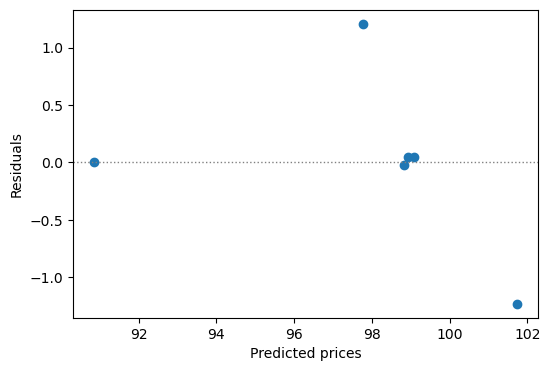

In [100]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.scatter(P_hat, residuals)
ax.axhline(0, lw=1, ls=':', color='grey')
ax.set_xlabel('Predicted prices')
ax.set_ylabel('Residuals')
plt.show()

From this quick analysis of residuals it might be that both bonds 2 and 6 are mispriced because they present the greatest residual values

Let's investigate another method in which we solve the system of linear equations by leaving one bond out every time

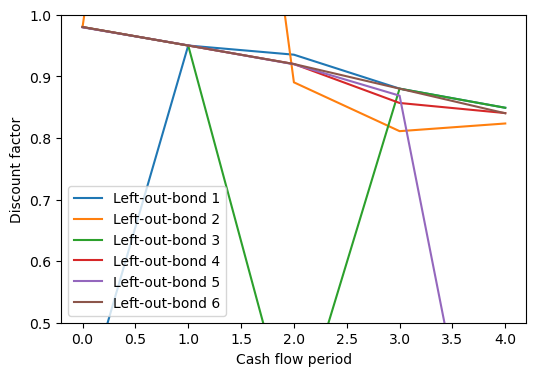

,Removed Bond,Left-Out Error,d_0.5,d_1.0,d_1.5,d_2.0,d_2.5
0,Bond 1,62.632625,0.359875,0.950000,0.935125,0.880000,0.848941
1,Bond 2,-126.832245,0.980000,2.169541,0.890255,0.810969,0.823437
2,Bond 3,62.012500,0.980000,0.950000,0.315000,0.880000,0.848941
3,Bond 4,2.466538,0.980000,0.950000,0.920000,0.856731,0.840344
4,Bond 5,85.278171,0.979529,0.950226,0.919537,0.868594,0.000000
5,Bond 6,-2.420000,0.980000,0.950000,0.920000,0.880000,0.840000


In [105]:
bond_names = np.array([
    "Bond 1",
    "Bond 2",
    "Bond 3",
    "Bond 4",
    "Bond 5",
    "Bond 6",
])

discount_factors = []

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
times = np.arange(CF.shape[1])

for i in range(len(P)):
    mask = np.arange(len(P)) != i
    CF_train = CF[mask]
    P_train = P[mask]
    d_hat, *_ = np.linalg.lstsq(CF_train, P_train, rcond=None)

    ax.plot(times, d_hat, label=f"Left-out-bond {i+1}")

    predicted_price = CF[i] @ d_hat
    left_out_error = P[i] - predicted_price

    discount_factors.append({
        "Removed Bond": bond_names[i],
        "Left-Out Error": left_out_error,
        "d_0.5": d_hat[0],
        "d_1.0": d_hat[1],
        "d_1.5": d_hat[2],
        "d_2.0": d_hat[3],
        "d_2.5": d_hat[4],
    })

ax.set_xlabel('Cash flow period')
ax.set_ylabel('Discount factor')
ax.set_ylim(0.5, 1)
ax.legend()
plt.show()

discount_factors = pd.DataFrame(discount_factors)
discount_factors

Note that discount factors should have the following properties: 
- should be positive
- should be below 1
- should decrease with maturity

From the plot and table we notice that when removing Bonds 4 or 6 we obtain discount factors with these properties, so most likely they are the mispriced ones

When removing other bonds, the solution provide unplausable discount factors so a mispriced bond must be still in the system of linear equations